<a href="https://colab.research.google.com/github/batuhanozdogn/ARIMA-NAR-ZAMAN-SER-S-/blob/main/global_temperature_prediction_arima_nar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kütüphane Kurulumları

In [30]:
#ARIMA için pmdarima kurulumu
!pip install pmdarima

#1. Veri İşleme
import pandas as pd
import numpy as np

#2. Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#3. Veri Ön İşleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.neural_network import MLPRegressor

#4. Zaman Serisi Analizi
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

#5. Derin Öğrenme Modeli (RNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

#6. Model Değerlendirme
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

EDA

In [31]:
df=pd.read_csv('/content/filtered_data.csv')

In [32]:
print(df.head())

  Source  Year    Mean
0   gcag  1850 -0.4177
1   gcag  1851 -0.2333
2   gcag  1852 -0.2294
3   gcag  1853 -0.2704
4   gcag  1854 -0.2915


In [33]:
df.shape

(319, 3)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Source  319 non-null    object 
 1   Year    319 non-null    int64  
 2   Mean    319 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 7.6+ KB


In [35]:
df.isna().sum()

,0
Source,0
Year,0
Mean,0


In [36]:
sum(df.duplicated())

0

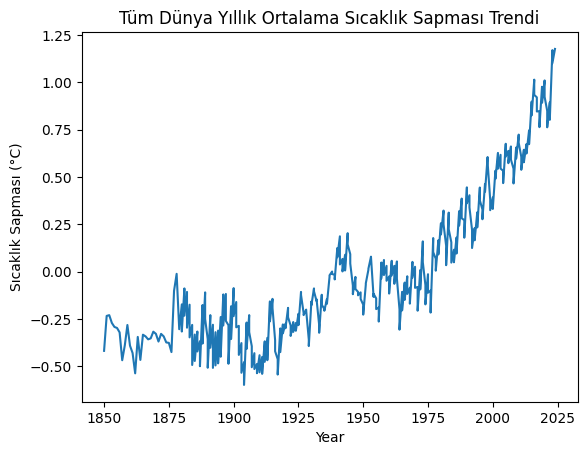

In [37]:
plt.plot(df['Year'], df['Mean'])
plt.title("Tüm Dünya Yıllık Ortalama Sıcaklık Sapması Trendi")
plt.xlabel("Year")
plt.ylabel("Sıcaklık Sapması (°C)")
plt.show()

In [38]:
result = adfuller(df['Mean'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: 2.043086710240321
p-value: 0.9987263881748983


ADF Statistic: 2.043,
(p-value: 0.9987 ≫ 0.05)
Yani: yıllık global sıcaklık serisi durağan değil.
Bu, seri trend içeriyor.

In [39]:
df['diff'] = df['Mean'].diff().dropna()

# Tekrar ADF testi
result = adfuller(df['diff'].dropna())
print(f"ADF Statistic (1st diff): {result[0]}")
print(f"p-value (1st diff): {result[1]}")

ADF Statistic (1st diff): -7.211849959133372
p-value (1st diff): 2.2242660745801312e-10


Bu kod, zaman serisi verisini durağan yapmak için fark alma işlemi yapıyor ve sonra ADF ile tekrar durağanlık test ediyor.
YORUM:Birinci fark alınmış seri üzerinde uygulanan ADF testi sonucunda ADF istatistiği -7.21(Çok Güçlü) ve p-değeri 2.22e-10 olarak bulunmuştur. p-değerinin 0.05’ten küçük olması nedeniyle sıfır hipotezi reddedilmiş ve serinin birinci farkı alındığında durağan hale geldiği sonucuna ulaşılmıştır.

(Orijinal seri durağan değildir ancak birinci fark alındığında seri durağan hale gelmektedir.)

!!!ARIMA KODU

geçmiş sıcaklık verilerini kullanarak bir zaman serisi modeli kuruyor ve gelecek 5 yılın sıcaklık anomalisi tahminini yapıyorsuz. NEDEN 5 yıl ARIMA kısa dönemde daha başarılıdır çünkü

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-286.703, Time=1.61 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-258.287, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-263.968, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-278.024, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-259.166, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-286.469, Time=1.12 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-288.657, Time=4.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-284.946, Time=1.28 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-280.311, Time=0.41 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-286.781, Time=1.81 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-288.680, Time=0.62 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-286.736, Time=1.23 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-286.037, Time=3.57 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-286.562, Time=0.24 sec

Best model:  ARIMA(3,1,0)(0,0,0)

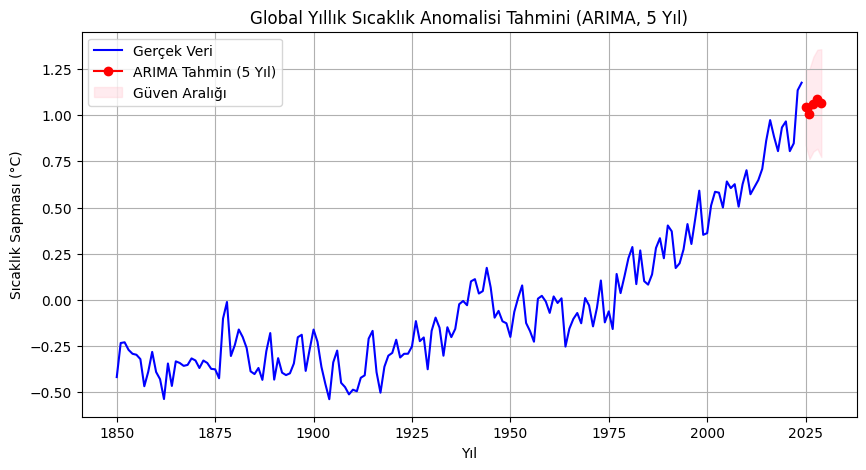

In [40]:
#  Veri yükleme
df_arima = df.copy()  # 'orijinal veriyi değiştirmemek için kopyasını alıyoruz sorun çıkmasın diye

# Bazı veri setlerinde aynı yıl için birden fazla kayıt olabilir. evet üstte yaptık ama garantici olmak en iyisi
df_arima = df_arima.groupby('Year')['Mean'].mean().reset_index()

df_arima['Year'] = pd.to_datetime(df_arima['Year'], format='%Y') # datetime formatına çevirir.2000,2001 gibi çünkü Zaman serisi modelleri tarih indeksli veri ister.
df_arima.set_index('Year', inplace=True)
df_arima.index.freq = 'YS' #Veri her yılın başında ölçülmüş yıllık veri. Bu ARIMA için önemli çünkü model zaman aralıklarını bilmek ister.YS=year start demek

#  Otomatik ARIMA ile en uygun (p,d,q) parametrelerini bul
model_auto = auto_arima(df_arima['Mean'], seasonal=False, stepwise=True, trace=True)
order = model_auto.order
print("Seçilen ARIMA parametreleri:", order)

# ARIMA modeli kur ve eğit
model = ARIMA(df_arima['Mean'], order=order) #Burada model yapısı oluşturuluyor. ama henüz eğitmedik
model_fit = model.fit() # model geçmiş veriden parametreleri öğrenir.
print(model_fit.summary())# Sonuçları yazdırdık Bu modelin istatistiksel kalitesini gösterir işte yaptığımız testleri p değerlinden büyükmü küçükmü vs diyerek

#  5 yıllık tahmin kısa dönem tahmin etmesini istediğimiz için
steps = 5
forecast = model_fit.get_forecast(steps=steps)
forecast_mean = forecast.predicted_mean #tahmin edilen sıcaklık değerleri.
forecast_ci = forecast.conf_int() # güven aralığı
forecast_years = range(df_arima.index[-1].year + 1, df_arima.index[-1].year + steps + 1)

# Güven aralıklarının Tahminlerinı DataFrame yaptık
forecast_5y_df = pd.DataFrame({
    'Year': forecast_years,
    'Forecast': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:,0].values,
    'Upper_CI': forecast_ci.iloc[:,1].values
})
print(forecast_5y_df)

#  Tahminleri görselleştir
plt.figure(figsize=(10,5))
plt.plot(df_arima.index.year, df_arima['Mean'], label="Gerçek Veri", color='blue')
plt.plot(forecast_years, forecast_mean, label="ARIMA Tahmin (5 Yıl)", color='red', marker='o')
plt.fill_between(forecast_years,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1], color='pink', alpha=0.3, label="Güven Aralığı")
plt.title("Global Yıllık Sıcaklık Anomalisi Tahmini (ARIMA, 5 Yıl)")
plt.xlabel("Yıl")
plt.ylabel("Sıcaklık Sapması (°C)")
plt.legend()
plt.grid(True)
plt.show()

ARIMA(3,1,0) ADF Testiyle uyumlu, AIC Testide ne kadar küçükse model o kadar iyi, AR katsayıları istatiksel olarak anlamlı P değerleri 0.05 ten küçük(anlamlı),Ljung-Box 0.88> 0.05 model uygundur Beyaz gürültüye maruz bırakılmamış ve Jarque-Bera 0.51> 0.05  normal dağılıma yakın

!!!NAR modeli iklim değişikliği gibi nonlinear ve gecikmeli etkilerin olduğu veri setleri için ARIMA gibi lineer modellere göre daha güçlü ve esnek bir tahmin aracı. ekstra olarak daha uzun yıllar için kullanılır

Eğitim Seti:
MAE: 0.12043442382185163
RMSE: 0.14526760836389174
R²: 0.5637902429377397

Test Seti:
MAE: 0.10738882951624404
RMSE: 0.13621983274535943
R²: 0.5502607592968846
Gelecek 10 Yıl Tahmini (NAR):
2025: 1.022 °C
2026: 1.027 °C
2027: 1.009 °C
2028: 1.182 °C
2029: 1.163 °C
2030: 1.295 °C
2031: 1.286 °C
2032: 1.264 °C
2033: 1.264 °C
2034: 1.275 °C


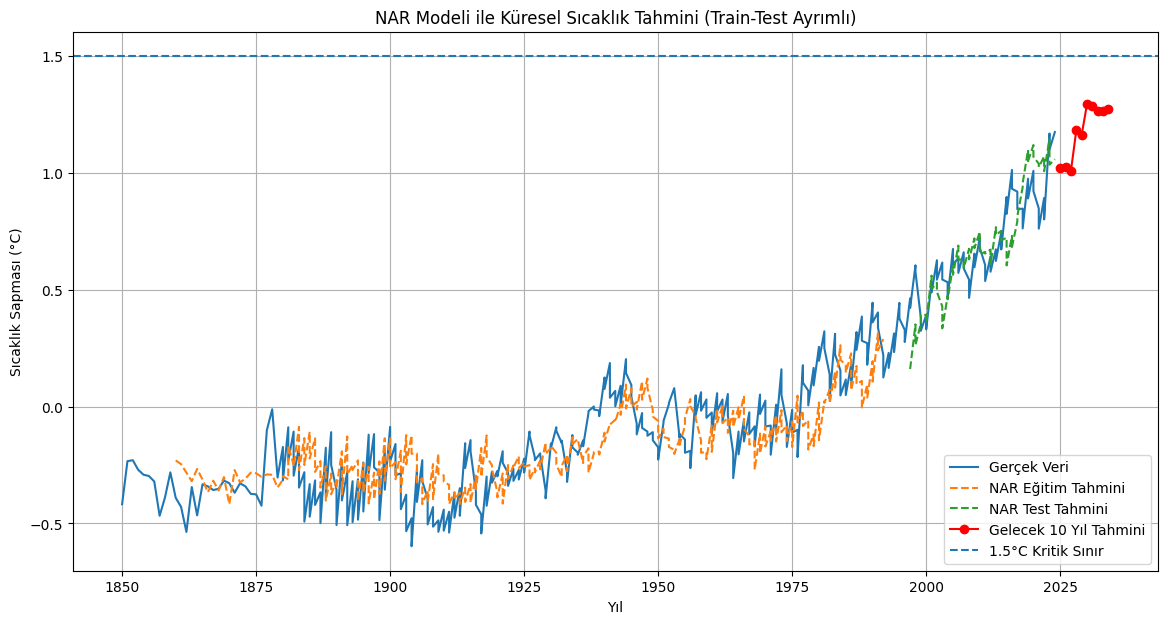

In [41]:
#Veri
series = df['Mean'].values.reshape(-1,1) #skitic learn için veriyi 2 boyuta indirgedik
years = df['Year'].values

#Ölçekleme
scaler = MinMaxScaler(feature_range=(-1,1)) # Makine öğrenmesinde daha iyi çalışmak için sayıları -1 ile 1 arasında sıkıştırdık
series_scaled = scaler.fit_transform(series)

#Train-Test Split
train_size = int(len(series_scaled)*0.8) #veriyi %80 test %20 tahmin olarak ayırrdık
train_scaled = series_scaled[:train_size]
test_scaled = series_scaled[train_size:]

#NAR veri seti oluşturma fonksiyonu
def create_nar_dataset(data, n_lags): #Geçmiş n yıl verisini kullanıp bir sonraki yılı tahmin etmeyi öğretir.
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y).ravel()

n_lags = 10 #10 yıl geçmiş → 1 yıl tahmin
X_train, y_train = create_nar_dataset(train_scaled, n_lags)
X_test, y_test = create_nar_dataset(test_scaled, n_lags)

#NAR Model (yapay sinir ağı oluştuduk)
model = MLPRegressor(hidden_layer_sizes=(20,),
                     activation='tanh',
                     solver='adam',
                     max_iter=2000,
                     random_state=42)
#Model eğitme geçmiş 10 yıl → sonraki yıl ilişkisini öğreniyor
model.fit(X_train, y_train)

#Tahminler
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# reshaplediğimiz ölçeği geri çeviriyoruz
y_train_pred_real = scaler.inverse_transform(y_train_pred.reshape(-1,1))
y_test_pred_real = scaler.inverse_transform(y_test_pred.reshape(-1,1))

# Düzeltme: y_train ve y_test zaten doğru boyutta olduğu için ek dilimlemeye gerek yok.
y_train_real = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

# Performans ölçüm
print("Eğitim Seti:")
print("MAE:", mean_absolute_error(y_train_real, y_train_pred_real))
print("RMSE:", np.sqrt(mean_squared_error(y_train_real, y_train_pred_real)))
print("R²:", r2_score(y_train_real, y_train_pred_real))

print("\nTest Seti:")
print("MAE:", mean_absolute_error(y_test_real, y_test_pred_real))
print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))
print("R²:", r2_score(y_test_real, y_test_pred_real))

#Gelecek 10 yıl tahmin
n_future = 10
input_seq = series_scaled[-n_lags:].flatten().tolist()
forecast_scaled = []

for _ in range(n_future):
    x_input = np.array(input_seq[-n_lags:]).reshape(1,-1)
    yhat = model.predict(x_input)[0]
    forecast_scaled.append(yhat)
    input_seq.append(yhat)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1))
forecast_years = np.arange(years[-1]+1, years[-1]+1+n_future)

#10 yıllık tahminleri yazdırma
print("Gelecek 10 Yıl Tahmini (NAR):")
for year, value in zip(forecast_years, forecast.flatten()):
    print(f"{year}: {value:.3f} °C")

#Grafik
plt.figure(figsize=(14,7))
plt.plot(years, series, label="Gerçek Veri")
plt.plot(years[n_lags:train_size], y_train_pred_real, '--', label="NAR Eğitim Tahmini")
plt.plot(years[train_size+n_lags:], y_test_pred_real, '--', label="NAR Test Tahmini")
plt.plot(forecast_years, forecast, 'ro-', label="Gelecek 10 Yıl Tahmini")
plt.axhline(1.5, linestyle='--', label="1.5°C Kritik Sınır")
plt.xlabel("Yıl")
plt.ylabel("Sıcaklık Sapması (°C)")
plt.title("NAR Modeli ile Küresel Sıcaklık Tahmini (Train-Test Ayrımlı)")
plt.legend()
plt.grid(True)
plt.show()

NAR modeli tatmin edici bir tahmin performansı göstermiştir. Eğitim setinde MAE ve RMSE değerleri sırasıyla 0.120 ve 0.145 olarak elde edilmiştir. Test setinde ise MAE değeri 0.107 ve RMSE değeri 0.136 olarak hesaplanmış olup, eğitim setine göre biraz daha düşük hata değerleri gözlemlenmiştir. Eğitim seti için yaklaşık 0.56 ve test seti için yaklaşık 0.55 olarak hesaplanan R² değerleri, modelin sıcaklık anomalisi serisindeki değişkenliğin yarısından fazlasını açıklayabildiğini göstermektedir.

Ayrıca eğitim ve test sonuçlarının birbirine oldukça yakın olması, modelin aşırı uyum (overfitting) problemi yaşamadığını ve görülmemiş veriler üzerinde de genelleme yapabilme kapasitesine sahip olduğunu göstermektedir. On yıllık tahmin sonuçları küresel sıcaklık anomalilerinde artış eğiliminin devam edeceğini göstermekte olup, 2034 yılına gelindiğinde değerin yaklaşık 1.27 °C seviyesine ulaşacağı öngörülmektedir. Bu durum, küresel sıcaklık artışının 1.5 °C olarak kabul edilen kritik eşiğe kademeli olarak yaklaştığını göstermektedir.


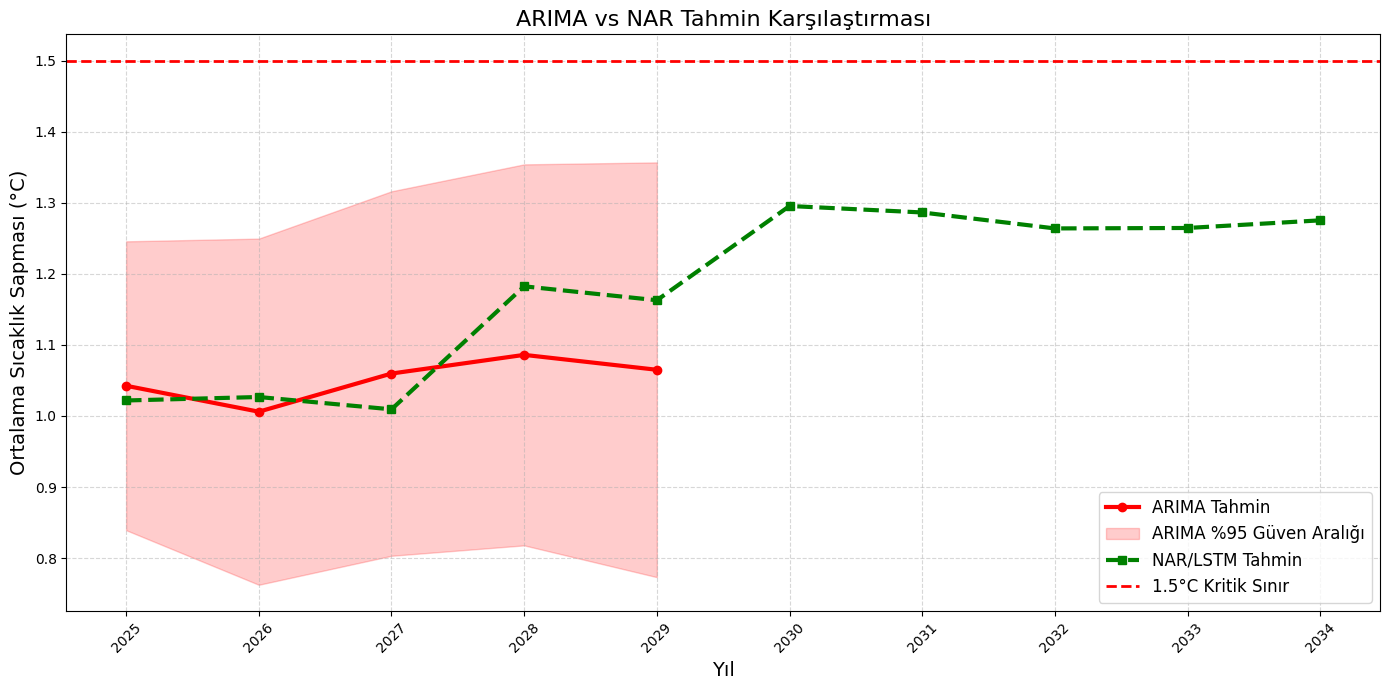

In [42]:
plt.figure(figsize=(14,7))

# ARIMA tahmini
arima_years = forecast_5y_df['Year']
arima_forecast = forecast_5y_df['Forecast']

# güven aralığı
lower = forecast_5y_df['Lower_CI']
upper = forecast_5y_df['Upper_CI']

plt.plot(arima_years, arima_forecast, 'ro-', label='ARIMA Tahmin', linewidth=3)

# güven aralığı gölgesi
plt.fill_between(arima_years, lower, upper, color='red', alpha=0.2, label='ARIMA %95 Güven Aralığı')

# NAR / LSTM tahmini
lstm_years = forecast_years
lstm_forecast = forecast

plt.plot(lstm_years, lstm_forecast, 'gs--', label='NAR/LSTM Tahmin', linewidth=3)

# kritik sınır
plt.axhline(1.5, color='red', linestyle='--', label='1.5°C Kritik Sınır', linewidth=2)

# X ekseni
plt.xticks(
    np.arange(min(arima_years.min(), lstm_years.min()),
              max(lstm_years.max(), arima_years.max())+1, 1),
    rotation=45
)

plt.xlabel('Yıl', fontsize=14)
plt.ylabel('Ortalama Sıcaklık Sapması (°C)', fontsize=14)
plt.title('ARIMA vs NAR Tahmin Karşılaştırması', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()